<a href="https://colab.research.google.com/github/RishitKothari12/Loan-Approval-Prediction/blob/main/Copy_of_PDS_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#Data Cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,precision_recall_curve
from sklearn.linear_model import LogisticRegression,LinearRegression, ElasticNet
# Load the dataset
df = pd.read_csv('Loan_Approval_Data_Train.csv')
print('\nDataset summary : \n',pd.concat([df.describe().drop('count')]).T)
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

# List of numerical columns that have missing values
numerical_columns_with_missing = [col for col in df.select_dtypes(include=np.number) if df[col].isnull().sum() > 0]

# Dictionary to store standard deviation changes
std_dev_changes = {}

# Imputation and Standard Deviation Change Calculation
for column in numerical_columns_with_missing:
    original_std_dev = df[column].std()

    # Mean Imputation
    df_mean_imputed = df.copy()
    df_mean_imputed[column].fillna(df_mean_imputed[column].mean(), inplace=True)
    mean_imputed_std_dev = df_mean_imputed[column].std()
    mean_change = abs(mean_imputed_std_dev - original_std_dev)

    # Median Imputation
    df_median_imputed = df.copy()
    df_median_imputed[column].fillna(df_median_imputed[column].median(), inplace=True)
    median_imputed_std_dev = df_median_imputed[column].std()
    median_change = abs(median_imputed_std_dev - original_std_dev)

    # Mode Imputation
    df_mode_imputed = df.copy()
    df_mode_imputed[column].fillna(df_mode_imputed[column].mode()[0], inplace=True)
    mode_imputed_std_dev = df_mode_imputed[column].std()
    mode_change = abs(mode_imputed_std_dev - original_std_dev)

    # Store the imputation method with the smallest change in standard deviation
    if mean_change <= median_change and mean_change <= mode_change:
        chosen_imputation = 'mean'
        df[column].fillna(df[column].mean(), inplace=True)
    elif median_change <= mean_change and median_change <= mode_change:
        chosen_imputation = 'median'
        df[column].fillna(df[column].median(), inplace=True)
    else:
        chosen_imputation = 'mode'
        df[column].fillna(df[column].mode()[0], inplace=True)

    std_dev_changes[column] = {
        'original_std_dev': original_std_dev,
        'mean_change': mean_change,
        'median_change': median_change,
        'mode_change': mode_change,
        'chosen_imputation': chosen_imputation
    }

# Display chosen imputation methods and standard deviation changes for each column
# However no changes made in our data
print("\nImputation Summary (Standard Deviation Changes):")
for col, details in std_dev_changes.items():
    print(f"{col}:")
    for key, value in details.items():
        print(f"  {key}: {value}")


Dataset summary : 
                                     mean           std      min       25%  \
id                          29322.000000  16929.497605     0.00  14661.00   
person_age                     27.550857      6.033216    20.00     23.00   
person_income               64046.172871  37931.106979  4200.00  42000.00   
person_emp_length               4.701015      3.959784     0.00      2.00   
loan_amnt                    9217.556518   5563.807384   500.00   5000.00   
loan_int_rate                  10.677874      3.034697     5.42      7.88   
loan_percent_income             0.159238      0.091692     0.00      0.09   
cb_person_cred_hist_length      5.813556      4.029196     2.00      3.00   
loan_status                     0.142382      0.349445     0.00      0.00   

                                 50%       75%         max  
id                          29322.00  43983.00    58644.00  
person_age                     26.00     30.00      123.00  
person_income            

Features in dataset:  Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')


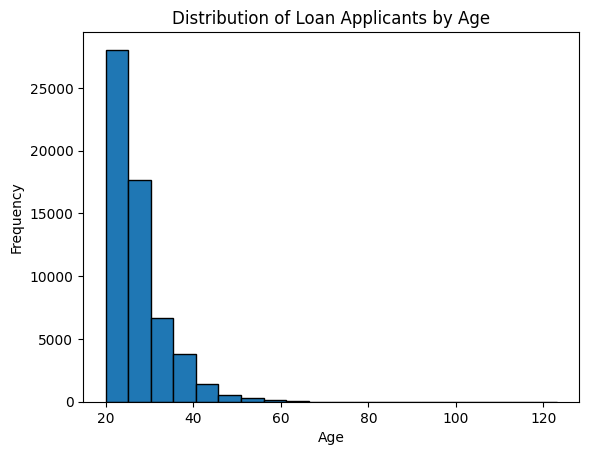

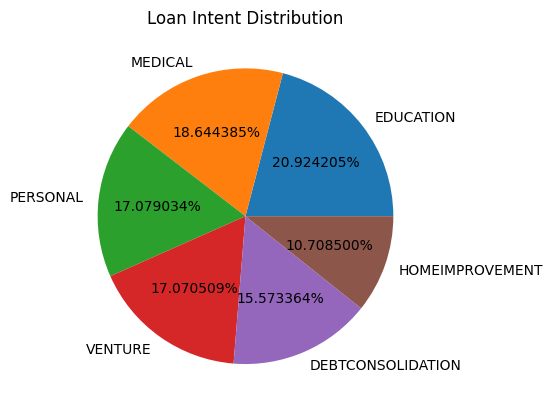

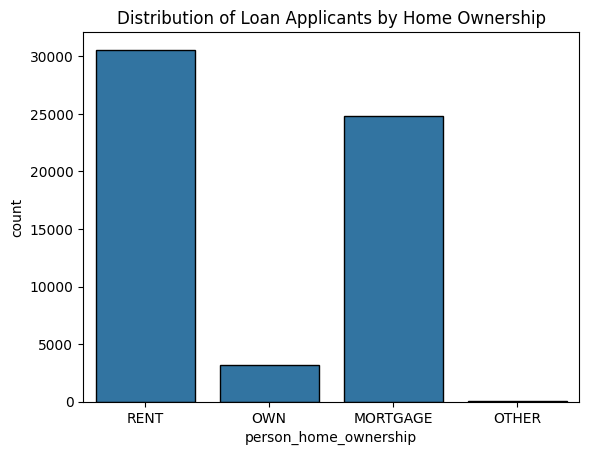

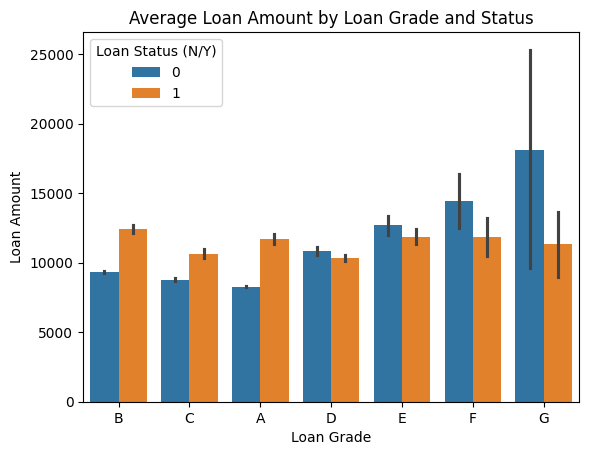

In [15]:
#data visualisation
print("Features in dataset: ",df.columns)
plt.hist(df['person_age'], bins=20, edgecolor='black')  # bins=20 is an arbitrary choice, adjust if needed
plt.title('Distribution of Loan Applicants by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.pie(df['loan_intent'].value_counts(),labels = df['loan_intent'].value_counts().index,autopct = '%f%%')
plt.title("Loan Intent Distribution")
plt.show()

sns.countplot(data=df, x='person_home_ownership', edgecolor='black')
plt.title('Distribution of Loan Applicants by Home Ownership')
plt.show()

sns.barplot(x='loan_grade', y='loan_amnt', hue='loan_status', data=df)
plt.title('Average Loan Amount by Loan Grade and Status')
plt.xlabel('Loan Grade')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status (N/Y)')
plt.show()

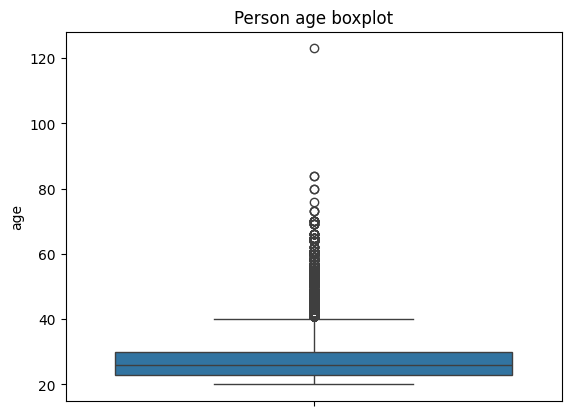

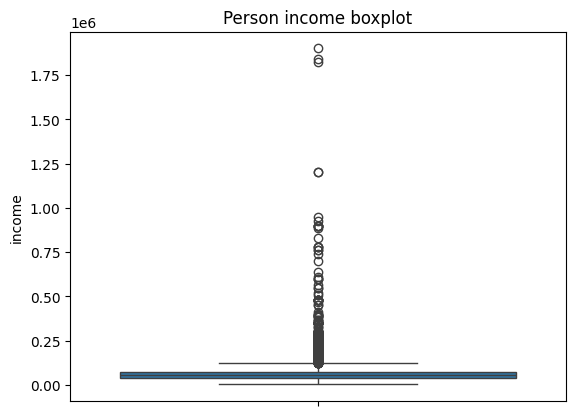

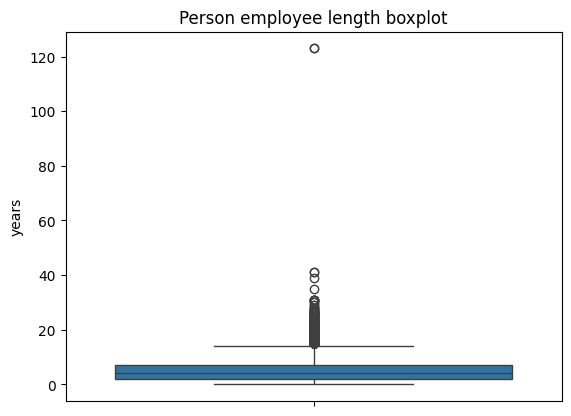

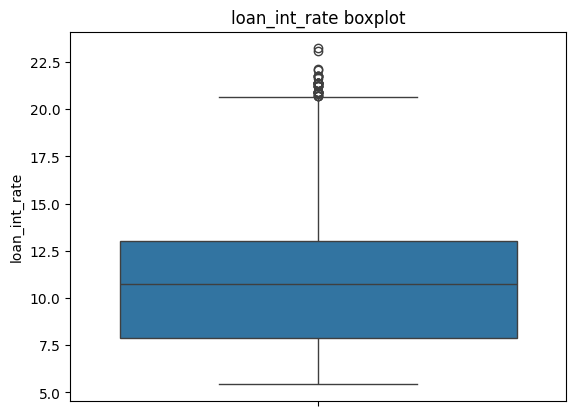

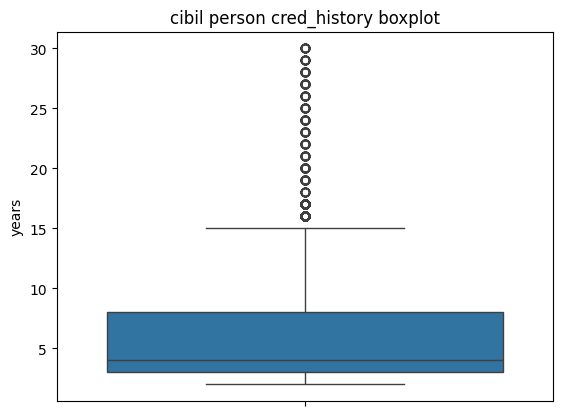

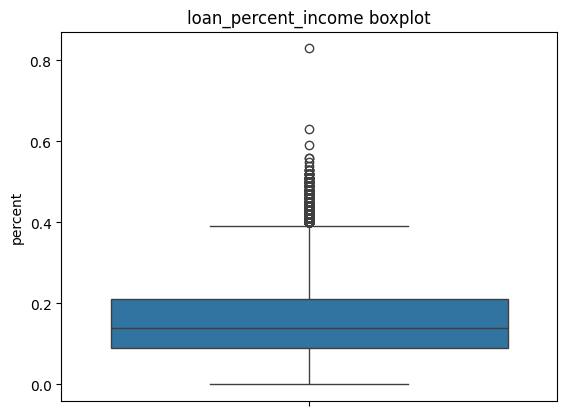

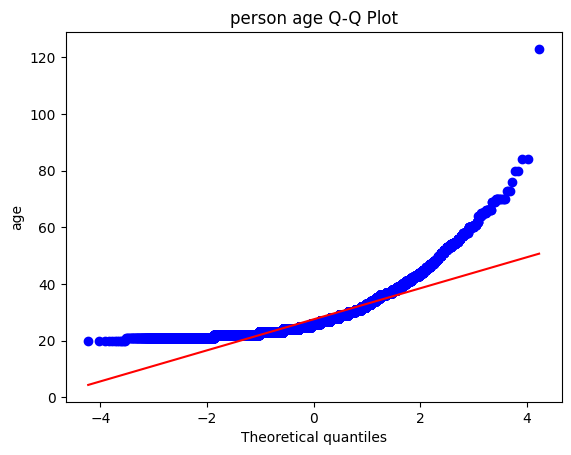

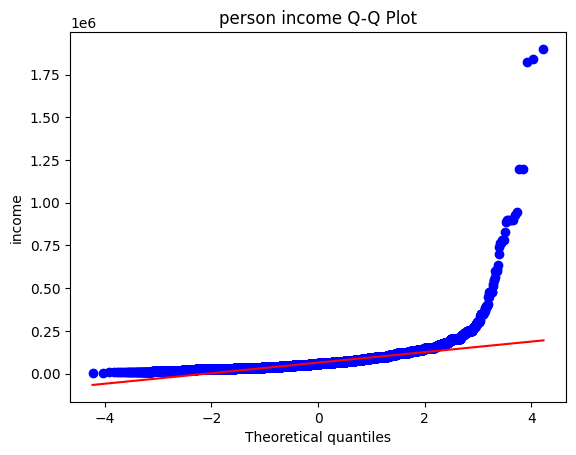

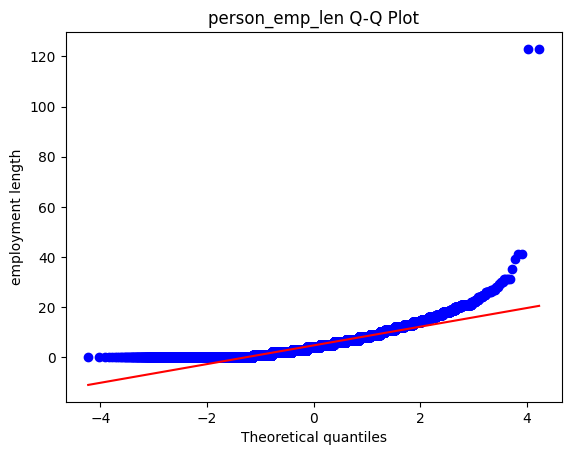

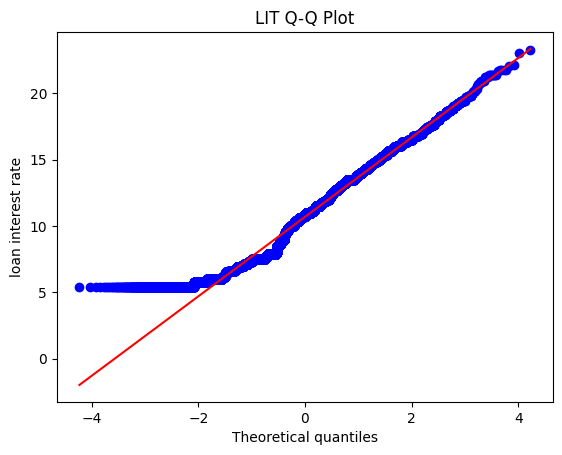

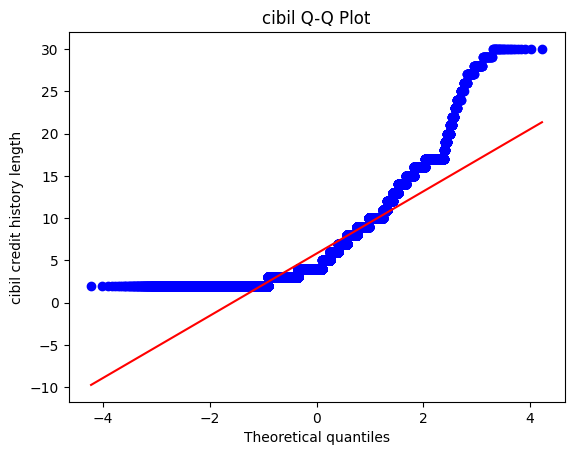

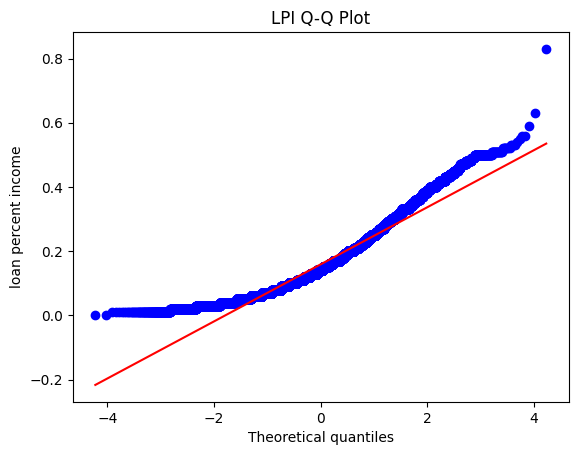

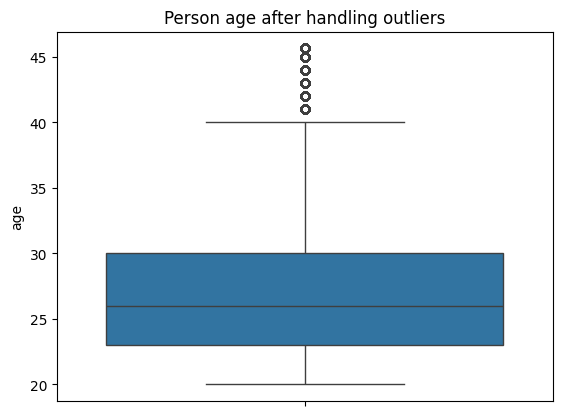

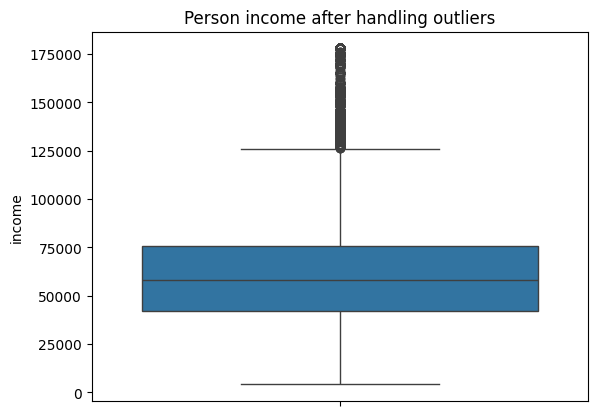

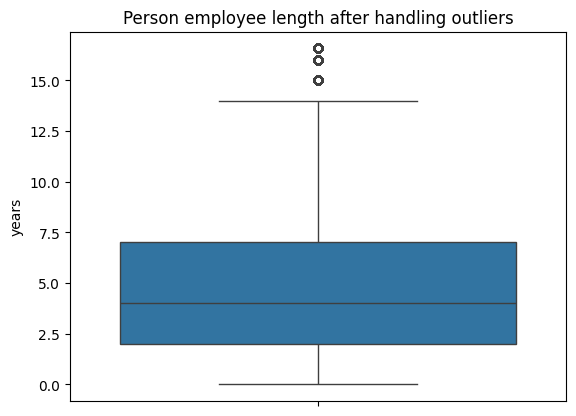

In [16]:
#***DROPPING UNNECESSARY COLUMN
df.drop(columns = ['id'], inplace = True)

#***HANDLING OUTLIERS
#NUMERICAL COLUMNS : person_age,person_income,person_emp_length,loan_int_rate,cb_person_hist_length,loan_percent_inc
#Plotting boxplot to notice outliers and Q-Q plot to determin whether its normally distributed or skewed
sns.boxplot( data =df['person_age'] )
plt.title('Person age boxplot')
plt.ylabel('age')
plt.show()

sns.boxplot( data =df['person_income'] )
plt.title('Person income boxplot')
plt.ylabel('income')
plt.show()

sns.boxplot(data =df['person_emp_length'])
plt.title('Person employee length boxplot')
plt.ylabel('years')
plt.show()

sns.boxplot( data =df['loan_int_rate'] )
plt.title('loan_int_rate boxplot')
plt.ylabel('loan_int_rate')
plt.show()

sns.boxplot( data =df['cb_person_cred_hist_length'] )
plt.title('cibil person cred_history boxplot')
plt.ylabel('years')
plt.show()

sns.boxplot( data =df['loan_percent_income'])
plt.title('loan_percent_income boxplot')
plt.ylabel('percent')
plt.show()

# Q-Q plot to check for normality
stats.probplot(df['person_age'], dist="norm", plot=plt)
plt.ylabel('age')
plt.title('person age Q-Q Plot')
plt.show()

stats.probplot(df['person_income'], dist="norm", plot=plt)
plt.ylabel('income')
plt.title('person income Q-Q Plot')
plt.show()

stats.probplot(df['person_emp_length'], dist="norm", plot=plt)
plt.title('person_emp_len Q-Q Plot')
plt.ylabel('employment length')
plt.show()

stats.probplot(df['loan_int_rate'], dist="norm", plot=plt)
plt.title('LIT Q-Q Plot')
plt.ylabel('loan interest rate')
plt.show()

stats.probplot(df['cb_person_cred_hist_length'], dist="norm", plot=plt)
plt.ylabel('cibil credit history length')
plt.title('cibil Q-Q Plot')
plt.show()

stats.probplot(df['loan_percent_income'], dist="norm", plot=plt)
plt.ylabel('loan percent income')
plt.title('LPI Q-Q Plot')
plt.show()

#Here extreme values loan_int_rate,cb_person_hist_length,loan_percent_inc actually affect overall approval greatly hence they are not handled
# that leaves us with person_age,person_income,person_emp_length and notice that q-q plot is fairly normal for all features.
# handling outliers via cap method as they still effect overall approval.
df_handled = df.copy()
columns_to_check = ['person_age','person_income','person_emp_length']

for col in columns_to_check:
    z_scores = stats.zscore(df[col])
    outliers = np.where(np.abs(z_scores) > 3)
    upper_limit = df_handled[col].mean() + 3 * df[col].std()
    lower_limit = df_handled[col].mean() - 3 * df[col].std()
    # Clip the outliers
    df_handled[col] = np.clip(df_handled[col], lower_limit, upper_limit)

sns.boxplot( data =df_handled['person_age'] )
plt.title('Person age after handling outliers')
plt.ylabel('age')
plt.show()

sns.boxplot( data =df_handled['person_income'] )
plt.title('Person income after handling outliers')
plt.ylabel('income')
plt.show()

sns.boxplot(data =df_handled['person_emp_length'])
plt.title('Person employee length after handling outliers')
plt.ylabel('years')
plt.show()

In [17]:
#***ENCODING
print('Categorical column values:\n\n',df['loan_intent'].value_counts(),'\n\n',df['person_home_ownership'].value_counts())
print('\n\n',df['loan_grade'].value_counts(),'\n\n',df['cb_person_default_on_file'].value_counts())
#Now handling categorical columns:
# loan grade(A,B,C,D,E,F,G),cb_person_default_on_file(Y,N),
# loan_intent(EDUCATION,MEDICAL,PERSONAL,VENTURE,DEBTCONSOLIDATION,HOMEIMPROVEMENT), person_home_ownership(RENT,MORTGAGE,OWN,OTHER).
# Applying labe encoding on loan grade and cb_person_default_on_file
# and One hot encoding on loan_intent and person_home_ownership

label_encoder = LabelEncoder()
df_handled['loan_grade'] = label_encoder.fit_transform(df_handled['loan_grade'])
df_handled['cb_person_default_on_file'] = label_encoder.fit_transform(df_handled['cb_person_default_on_file'])

df_transformed = pd.get_dummies(df_handled, columns=['loan_intent', 'person_home_ownership'])
print("\nAfter data preprocessing: \n",df_transformed.columns,"\nshape:",df_transformed.shape)

Categorical column values:

 loan_intent
EDUCATION            12271
MEDICAL              10934
PERSONAL             10016
VENTURE              10011
DEBTCONSOLIDATION     9133
HOMEIMPROVEMENT       6280
Name: count, dtype: int64 

 person_home_ownership
RENT        30594
MORTGAGE    24824
OWN          3138
OTHER          89
Name: count, dtype: int64


 loan_grade
A    20984
B    20400
C    11036
D     5034
E     1009
F      149
G       33
Name: count, dtype: int64 

 cb_person_default_on_file
N    49943
Y     8702
Name: count, dtype: int64

After data preprocessing: 
 Index(['person_age', 'person_income', 'person_emp_length', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_status', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'person_home_ownership_M

In [18]:
#***SCALING
from sklearn.preprocessing import StandardScaler, MinMaxScaler
mmscaler = MinMaxScaler()
mmscaled_df = pd.DataFrame(mmscaler.fit_transform(df_transformed.drop(columns=['loan_status'])),columns=df_transformed.drop(columns =['loan_status']).columns)
stdscaler = StandardScaler()
stdscaled_df = pd.DataFrame(stdscaler.fit_transform(df_transformed.drop(columns =['loan_status'])),columns=df_transformed.drop(columns =['loan_status']).columns)
stdscaled_df['loan_status'] = df_transformed['loan_status']
mmscaled_df['loan_status'] = df_transformed['loan_status']

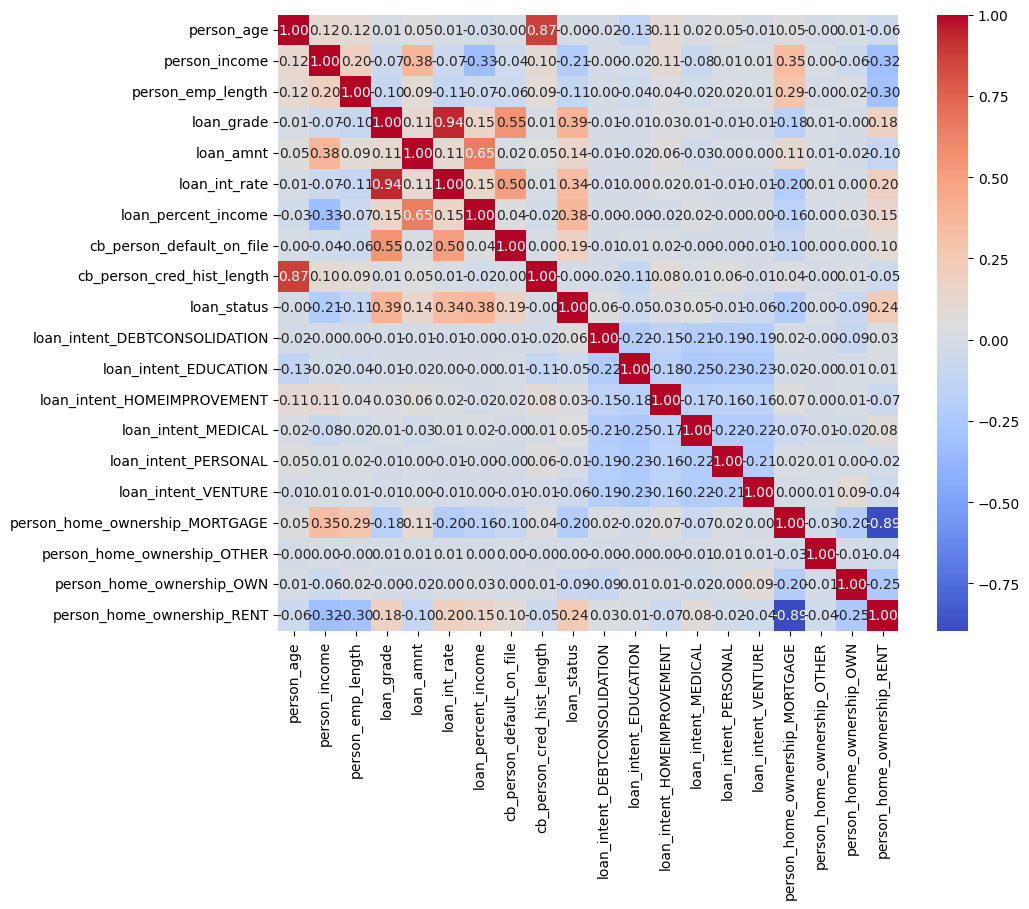

In [19]:
#FINAL CORRELATION
cor_mat3 = df_transformed.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(cor_mat3, fmt='.2f', annot=True, cmap='coolwarm')
plt.show()

loan_status
0    50295
1     8350
Name: count, dtype: int64


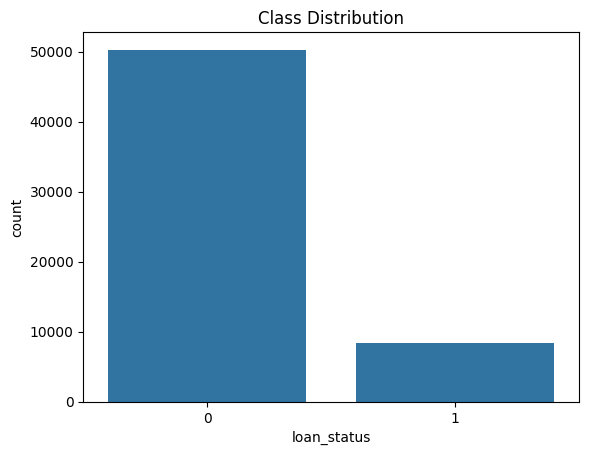

Conclusion: The dataset is Imbalanced


In [20]:
y = df_transformed['loan_status']
x = df_transformed.drop(columns =['loan_status'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(y.value_counts())
sns.countplot(x='loan_status', data=df)
plt.title('Class Distribution')
plt.show()
print("Conclusion: The dataset is Imbalanced")

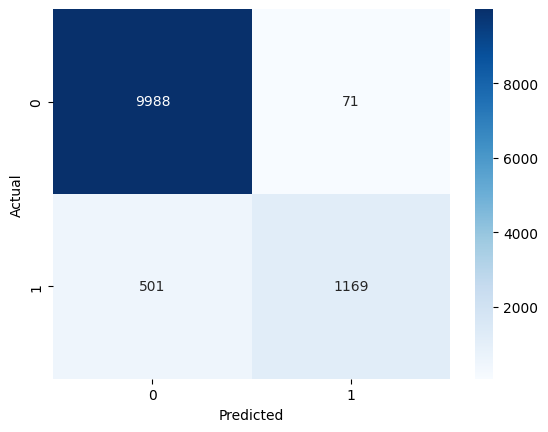

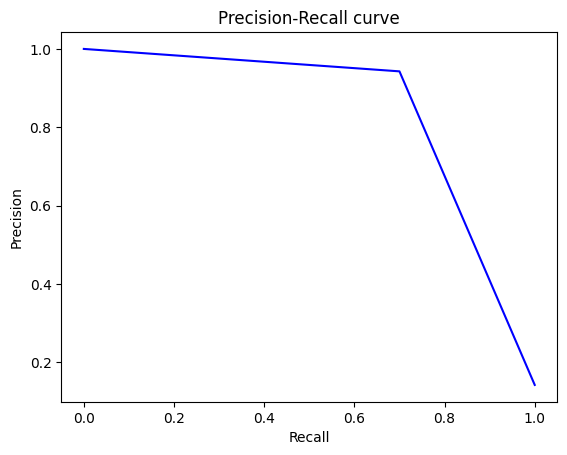

Specificity: 0.9929416442986381
Recall: 0.9512319890868787
Balanced Accuracy: 0.846470822149319
Precision: 0.9508839365509559
Accuracy: 0.9512319890868787
F1 Score: 0.9481391288534197
BIAS: 0.03666126694517863
Variance: 0.09454396198353385

Prediction vs Actual:
        Actual  Predicted
18964       0          0
32930       0          0
37397       0          0
12525       0          0
56389       0          0


In [21]:
# Random Forest Classifier as a baseline model
y = stdscaled_df['loan_status']
x = stdscaled_df.drop(columns =['loan_status'])

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(random_state=42, class_weight='balanced')

model.fit(X_train_scaled, y_train)

# Step 6: Prediction and Evaluation
# Predicting the loan status
y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticklabels=['No', 'Yes']
plt. yticklabels=['No', 'Yes']
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
plt.plot(recall, precision, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
balanced_accuracy = (sensitivity + specificity) / 2
# Calculate Evaluation Metrics
precision = precision_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print Evaluation Metrics
print(f'Specificity: {specificity}')
print(f"Recall: {recall}")
print(f'Balanced Accuracy: {balanced_accuracy}')
print(f"Precision: {precision}")
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print("BIAS:",  np.mean(y_test) - np.mean(y_pred))
print("Variance:",   np.var( y_pred))

# Visualizing feature importance
importances = model.feature_importances_
features = x_train.columns
indices = np.argsort(importances)[::-1]

# Display Prediction vs Actual data
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPrediction vs Actual:\n", results_df.head())  # Displaying the first few rows for comparison


##CONCLUSION
# High specificity: the model is correctly identifying 99.15% of no cases, which indicates it barely classifies a No loan as a Yes.
# High sensitivty: It’s an indication of how well the model catches all the YES cases.
# A balanced accuracy of 0.8518 means model is doing a decent job across both classes while accounting for any class imbalance.
# High precision : 95.1% of the loans predicted as yes are correct. and other small amount is actually no
# An F1 score of 94.9% shows that the model has a good trade-off between predicting yes correctly and not falsely classifying no loans as yes.
# Accuracy of 95.2% suggests that your model is highly accurate.
# low positive bias shows model is accurate and on average our model is slightly over-predicting yes cases
# low variance of 0.0968 suggests that your model is not excessively overfitting or underfitting.

In [22]:
#SAMPLE INPUT
df_input = pd.read_csv('Loan_Approval_Data_Test.csv')
x_input = df_input.drop(columns = ['id'])
x_input['loan_grade'] = label_encoder.fit_transform(x_input['loan_grade'])
x_input['cb_person_default_on_file'] = label_encoder.fit_transform(x_input['cb_person_default_on_file'])
x_input = pd.get_dummies(x_input, columns=['loan_intent', 'person_home_ownership'])
y_output = model.predict(x_input)

# Display Prediction vs Actual data
output = pd.DataFrame({'Predicted': y_output})
print("\nOutput:\n", output)


Output:
        Predicted
0              0
1              0
2              0
3              0
4              0
...          ...
39093          0
39094          0
39095          0
39096          0
39097          0

[39098 rows x 1 columns]


In [23]:
# Save the model for later use
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)